Rule: Forehead/Chest-এর সঙ্গে fair comparison রাখতে preprocessing + features + model একই থাকবে। শুধু ROI বদলাবে।

In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm

In [2]:
import os, glob
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, skew, kurtosis

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(sayem, "**", ext), recursive=True)

print("Total images found:", len(all_imgs))
print("Sample:", all_imgs[:5])

Total images found: 760
Sample: ['/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1024).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (566).jpg']


Labeling (same as before)

In [5]:
def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice","icteric","positive","pos","case","patient","affected","yellow"]
    neg_keys = ["normal","control","negative","neg","healthy","non"]
    if any(k in lp for k in pos_keys): return 1
    if any(k in lp for k in neg_keys): return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p,l) for p,l in pairs if l is not None]

imgs = [p for p,l in pairs]
y = np.array([l for p,l in pairs])

print("Labeled:", len(imgs))
print("Class counts (0=Normal,1=Jaundice):", np.bincount(y))

Labeled: 760
Class counts (0=Normal,1=Jaundice): [560 200]


Abdomen ROI (Core change)

Abdomen (belly) সাধারণত chest-এর নিচে, lower-middle zone.

In [6]:
def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]

    # central width 50%
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)

    # abdomen zone (lower middle)
    y1 = int(0.60 * h)
    y2 = int(0.92 * h)

    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

Preprocess

In [7]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0
    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))
    out = cv2.merge([b,g,r])
    return np.clip(out, 0, 255).astype(np.uint8)

def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr

Skin Mask (same)

In [8]:
def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    k = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    return mask

Feature extraction (same as chest/forehead)

In [9]:
def masked_stats(channel, mask):
    vals = channel[mask==255].astype(np.float32)
    if vals.size < 30:
        return (np.nan,)*6
    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )

def extract_features_from_roi(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)
    if np.sum(mask==255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8)*255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:,:,0]; G = roi_rgb[:,:,1]; B = roi_rgb[:,:,2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))
    rg_balance = float((Rm - Gm) / (Rm + Gm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom); g_ch = float(Gm / denom); b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:,:,0]; S = hsv[:,:,1]; V = hsv[:,:,2]
    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask==255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0,180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:,:,0]; a = lab[:,:,1]; b = lab[:,:,2]
    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask==255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,

        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "RG_balance": rg_balance,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,

        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,

        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }
    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

Build Abdomen feature dataset

In [10]:
rows = []
failed = 0

for p, label in tqdm(pairs, total=len(pairs)):
    img = cv2.imread(p)
    if img is None:
        failed += 1
        continue

    roi = extract_abdomen_roi(img)
    if roi is None:
        failed += 1
        continue

    feats = extract_features_from_roi(roi)
    feats["label"] = int(label)
    feats["path"] = p
    rows.append(feats)

feat_df_abdomen = pd.DataFrame(rows)

print("Abdomen features:", feat_df_abdomen.shape)
print("Failed:", failed)
print("Label distribution:\n", feat_df_abdomen["label"].value_counts())
feat_df_abdomen.head()

100%|██████████| 760/760 [01:56<00:00,  6.54it/s]

Abdomen features: (760, 29)
Failed: 0
Label distribution:
 label
0    560
1    200
Name: count, dtype: int64


,R_mean,G_mean,B_mean,R_std,G_std,B_std,R_p90,G_p90,B_p90,YGI,...,V_std,Hue_peak_bin,L_mean,a_mean,Lab_b_mean,Lab_b_p90,yellow_prop,YGI_x_b,label,path
0,117.766014,105.502045,93.696655,28.167358,27.639208,27.049606,150.0,137.0,125.0,2.382882,...,28.167379,1.0,115.199997,130.831497,136.438614,140.0,0.229696,325.117093,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
1,151.865494,118.454918,98.776161,38.708691,42.716068,47.879982,200.0,183.0,174.0,2.736697,...,38.708691,1.0,133.264435,138.909378,144.334549,154.0,0.230641,394.999905,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
2,128.315277,100.175293,94.259315,45.169415,41.820202,42.934547,192.0,160.0,155.0,2.424064,...,45.169415,0.0,113.481529,138.528198,135.857864,140.0,0.212285,329.328092,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
3,177.885681,150.674805,143.505661,42.817516,40.706879,41.450752,213.0,186.0,180.0,2.289530,...,42.817516,0.0,163.562134,137.114136,135.620560,145.0,0.204689,310.507309,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
4,87.057594,82.939095,74.532394,31.533646,31.430147,30.754612,128.0,124.0,115.0,2.280843,...,31.533703,2.0,89.306404,128.047729,133.569687,135.0,0.150108,304.651479,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...


Correlation heatmap (with values)

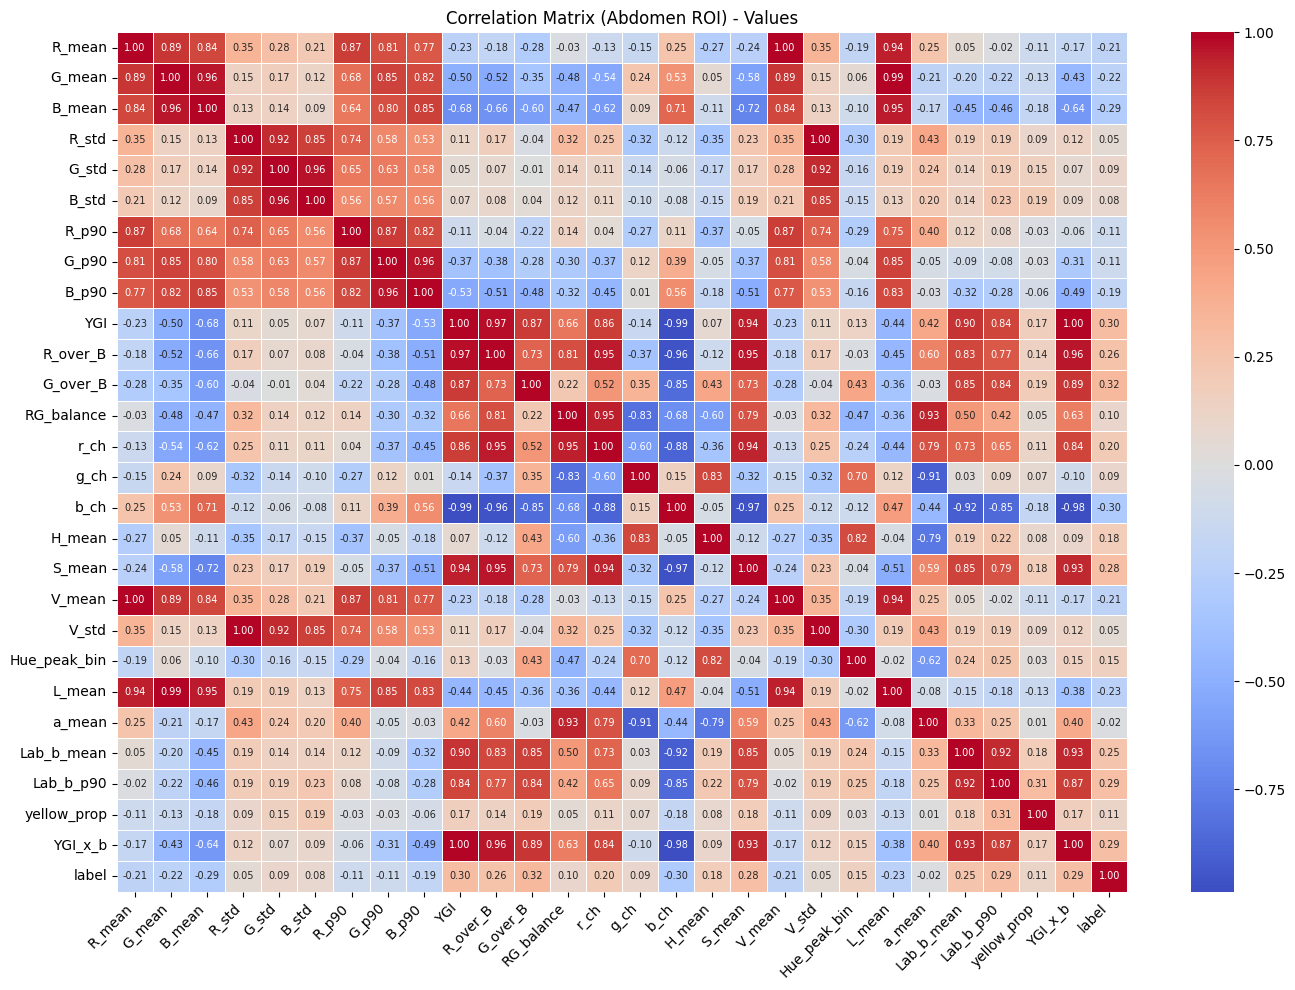

In [11]:
corr = feat_df_abdomen.drop(columns=["path"]).corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, linecolor="white", annot_kws={"size":7})
plt.title("Correlation Matrix (Abdomen ROI) - Values")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

t-test significant features

In [12]:
results = []
for col in feat_df_abdomen.columns:
    if col in ["label","path"]:
        continue
    c0 = feat_df_abdomen[feat_df_abdomen["label"]==0][col].dropna()
    c1 = feat_df_abdomen[feat_df_abdomen["label"]==1][col].dropna()
    if len(c0) < 10 or len(c1) < 10:
        continue
    t_stat, p_val = ttest_ind(c0, c1, equal_var=False)
    results.append({
        "Feature": col,
        "Mean_0": float(np.mean(c0)),
        "Mean_1": float(np.mean(c1)),
        "t_stat": float(t_stat),
        "p_value": float(p_val)
    })

ttest_df_abdomen = pd.DataFrame(results).sort_values("p_value")
ttest_df_abdomen["significant(p<0.05)"] = ttest_df_abdomen["p_value"] < 0.05
print(ttest_df_abdomen.head(15).round(6))

sig_feats_abdomen = ttest_df_abdomen[ttest_df_abdomen["p_value"] < 0.05]["Feature"].tolist()
print("\nSignificant features (Abdomen):", sig_feats_abdomen)

       Feature      Mean_0      Mean_1    t_stat  p_value  significant(p<0.05)
2       B_mean   98.071972   85.216212  8.120941      0.0                 True
15        b_ch    0.286601    0.273721  7.622225      0.0                 True
24   Lab_b_p90  143.175000  146.860000 -7.504941      0.0                 True
17      S_mean   70.394465   84.739665 -7.320350      0.0                 True
11    G_over_B    1.133044    1.199167 -7.353382      0.0                 True
9          YGI    2.501112    2.679814 -6.963613      0.0                 True
26     YGI_x_b  346.436157  377.431409 -6.843869      0.0                 True
23  Lab_b_mean  138.253755  140.388903 -6.778364      0.0                 True
21      L_mean  122.320278  112.480588  6.645467      0.0                 True
1       G_mean  110.349768  100.897732  6.318488      0.0                 True
18      V_mean  132.351152  122.977126  6.179341      0.0                 True
0       R_mean  132.350985  122.976988  6.179305    

Final Abdomen Model (SVM) + ROC/AUC + 5-fold CV

              precision    recall  f1-score   support

           0       0.85      0.73      0.79       112
           1       0.46      0.65      0.54        40

    accuracy                           0.71       152
   macro avg       0.66      0.69      0.67       152
weighted avg       0.75      0.71      0.72       152

Confusion Matrix:
 [[82 30]
 [14 26]]
Abdomen AUC: 0.7558035714285715


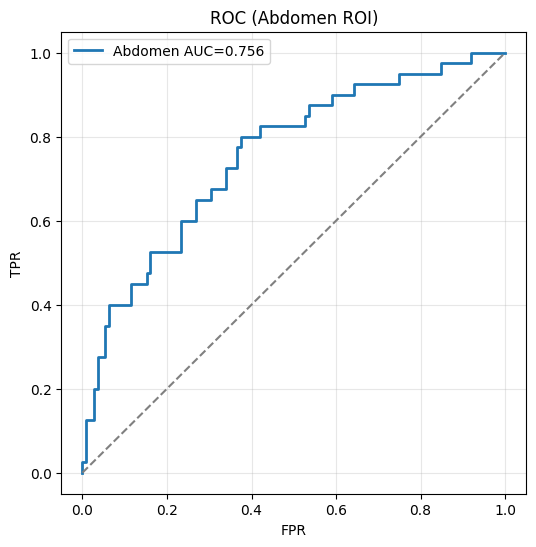

5-Fold CV AUC: [0.79799107 0.78236607 0.74330357 0.80758929 0.72299107]
Mean CV AUC: 0.7708482142857143


In [13]:
Xsig = feat_df_abdomen[sig_feats_abdomen]
y = feat_df_abdomen["label"]

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    Xsig, y, test_size=0.2, random_state=42, stratify=y
)

svm.fit(X_train, y_train)
pred = svm.predict(X_test)
prob = svm.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

fpr, tpr, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)
print("Abdomen AUC:", roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Abdomen AUC={roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC (Abdomen ROI)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

cv_auc = cross_val_score(svm, Xsig, y, cv=5, scoring="roc_auc")
print("5-Fold CV AUC:", cv_auc)
print("Mean CV AUC:", cv_auc.mean())

In [15]:
from sklearn.metrics import brier_score_loss
from sklearn.utils import resample

# Calculate Brier Score
bs = brier_score_loss(y_test, prob)
print(f"Abdomen Brier Score: {bs:.4f}")

# Calculate 95% Confidence Interval for Brier Score using bootstrapping
n_iterations = 2000
brier_scores_bootstrap = []

for i in range(n_iterations):
    # Bootstrap resample
    y_test_resample, prob_resample = resample(y_test, prob, stratify=y_test, random_state=i)
    # Calculate Brier score for the resample
    bs_resample = brier_score_loss(y_test_resample, prob_resample)
    brier_scores_bootstrap.append(bs_resample)

# Calculate the 95% confidence interval
alpha = 0.95
p = ((1.0 - alpha) / 2.0) * 100
lower = np.percentile(brier_scores_bootstrap, p)
p = (alpha + ((1.0 - alpha) / 2.0)) * 100
upper = np.percentile(brier_scores_bootstrap, p)

print(f"95% Confidence Interval for Brier Score: [{lower:.4f}, {upper:.4f}]")

Abdomen Brier Score: 0.1604
95% Confidence Interval for Brier Score: [0.1379, 0.1849]


Best Threshold for Accuracy: 0.51
Max Accuracy at this threshold: 0.7961
Abdomen AUC: 0.7558


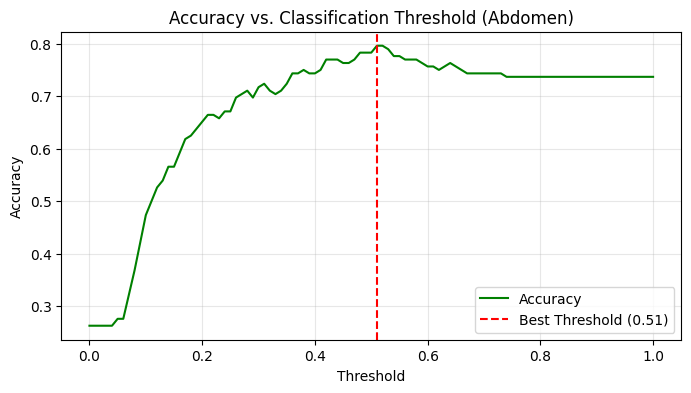

In [17]:
from sklearn.metrics import accuracy_score

# Find optimal threshold for accuracy
thresholds = np.linspace(0, 1, 101)
accuracies = []

for t in thresholds:
    y_pred_t = (prob >= t).astype(int)
    accuracies.append(accuracy_score(y_test, y_pred_t))

best_idx = np.argmax(accuracies)
best_threshold = thresholds[best_idx]
best_accuracy = accuracies[best_idx]

print(f"Best Threshold for Accuracy: {best_threshold:.2f}")
print(f"Max Accuracy at this threshold: {best_accuracy:.4f}")
print(f"Abdomen AUC: {roc_auc:.4f}")

# Optional: Visualization of Accuracy vs Threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, accuracies, label='Accuracy', color='green')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Classification Threshold (Abdomen)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

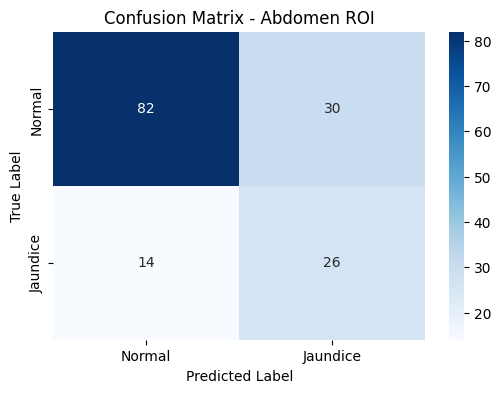

In [19]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Jaundice'],
            yticklabels=['Normal', 'Jaundice'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Abdomen ROI')
plt.show()

In [20]:
from sklearn.metrics import accuracy_score

# Standard accuracy (using 0.5 threshold)
acc = accuracy_score(y_test, pred)
print(f"Standard Test Accuracy (Threshold 0.50): {acc:.4f}")

# Best accuracy found in previous step
print(f"Optimal Test Accuracy (Threshold {best_threshold:.2f}): {best_accuracy:.4f}")

Standard Test Accuracy (Threshold 0.50): 0.7105
Optimal Test Accuracy (Threshold 0.51): 0.7961


In [21]:
print(f"Abdomen Test AUC: {roc_auc:.4f}")

Abdomen Test AUC: 0.7558


In [22]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils import resample

# y_test and prob must already exist from your notebook

def auc_bootstrap_ci(y_true, y_prob, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_b = y_true[idx]
        p_b = y_prob[idx]

        # skip invalid bootstrap samples with only one class
        if len(np.unique(y_b)) < 2:
            continue

        aucs.append(roc_auc_score(y_b, p_b))

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return lower, upper

def metrics_at_threshold(y_true, y_prob, thr):
    y_pred = (np.array(y_prob) >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "threshold": thr,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "specificity": spec,
        "f1": f1,
        "confusion_matrix": cm
    }

# 1) AUC and 95% CI
test_auc = roc_auc_score(y_test, prob)
auc_ci_low, auc_ci_high = auc_bootstrap_ci(np.array(y_test), np.array(prob))

print(f"Test AUC: {test_auc:.4f}")
print(f"95% CI for AUC: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")

# 2) Youden threshold
fpr, tpr, thresholds = roc_curve(y_test, prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
youden_thr = thresholds[best_idx]

print(f"Youden threshold: {youden_thr:.4f}")

# 3) Metrics at threshold 0.50
m_050 = metrics_at_threshold(np.array(y_test), np.array(prob), 0.50)
print("\nMetrics at threshold = 0.50")
for k, v in m_050.items():
    print(f"{k}: {v}")

# 4) Metrics at Youden threshold
m_youden = metrics_at_threshold(np.array(y_test), np.array(prob), youden_thr)
print("\nMetrics at Youden threshold")
for k, v in m_youden.items():
    print(f"{k}: {v}")

Test AUC: 0.7558
95% CI for AUC: [0.6652, 0.8414]
Youden threshold: 0.2200

Metrics at threshold = 0.50
threshold: 0.5
accuracy: 0.7828947368421053
precision: 0.64
recall: 0.4
specificity: 0.9196428571428571
f1: 0.49230769230769234
confusion_matrix: [[103   9]
 [ 24  16]]

Metrics at Youden threshold
threshold: 0.21995162239174065
accuracy: 0.6710526315789473
precision: 0.43243243243243246
recall: 0.8
specificity: 0.625
f1: 0.5614035087719298
confusion_matrix: [[70 42]
 [ 8 32]]
